<a href="https://colab.research.google.com/github/Vishvas027/Stock-Market-Trend-Analyzer/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fetch 2 years of history for a ticker (e.g., Apple)
ticker = "AAPL"
data = yf.download(ticker, start="2024-01-01", end="2026-03-01")
df = data[['Close']].copy() # We only need the Closing price

/tmp/ipykernel_584/698931800.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2024-01-01", end="2026-03-01")
[*********************100%***********************]  1 of 1 completed


In [13]:
# Create the trends using rolling windows
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

# Drop rows with NaN (the first 49 days won't have a 50-day average)
df.dropna(inplace=True)

In [14]:
# Use np.where for fast vectorised logic
df['Signal'] = np.where(df['SMA20'] > df['SMA50'], 1, 0)

# Calculate 'Position' to see exactly when the signal CHANGED (1 to 0 or 0 to 1)
df['Position'] = df['Signal'].diff()

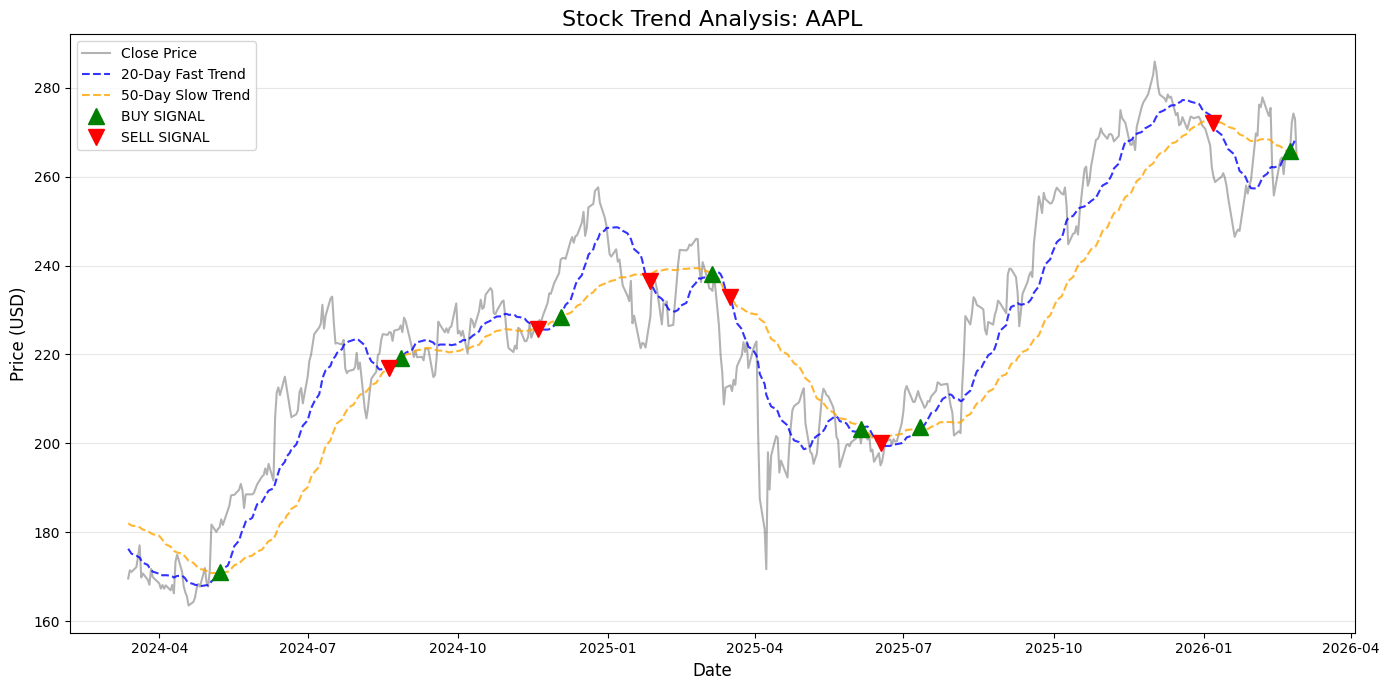

In [15]:
import matplotlib.pyplot as plt

# 1. Create the plot area
plt.figure(figsize=(14, 7))

# 2. Plot the Price and Moving Averages
plt.plot(df['Close'], label='Close Price', color='black', alpha=0.3, linewidth=1.5)
plt.plot(df['SMA20'], label='20-Day Fast Trend', color='blue', linestyle='--', alpha=0.8)
plt.plot(df['SMA50'], label='50-Day Slow Trend', color='orange', linestyle='--', alpha=0.8)

# 3. Plot BUY Signals (Green Up Arrows)
# We only plot if there are actually signals to avoid errors
buy_signals = df[df['Position'] == 1]
if not buy_signals.empty:
    plt.plot(buy_signals.index,
             df['SMA20'][df['Position'] == 1],
             '^', markersize=12, color='green', label='BUY SIGNAL', lw=0)

# 4. Plot SELL Signals (Red Down Arrows)
sell_signals = df[df['Position'] == -1]
if not sell_signals.empty:
    plt.plot(sell_signals.index,
             df['SMA20'][df['Position'] == -1],
             'v', markersize=12, color='red', label='SELL SIGNAL', lw=0)

# 5. Add Titles and Labels for a professional look
plt.title(f"Stock Trend Analysis: {ticker}", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend(loc='best')
plt.grid(axis='y', alpha=0.3)

# 6. Display the final chart
plt.tight_layout()
plt.show()